In [40]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
plt.style.use('default')
traffic_df = pd.read_csv("Metro_Interstate_Traffic_Volume.csv")
traffic_df = pd.DataFrame(traffic_df)


traffic_df['date_time'] = pd.to_datetime(traffic_df['date_time'], format='%d-%m-%Y %H:%M')
traffic_df = traffic_df.sort_values('date_time').reset_index(drop=True)

traffic_df['isHoliday'] = pd.notna(traffic_df['holiday']).astype('int')
traffic_df['hour']=traffic_df['date_time'].dt.hour
traffic_df['dayOfWeek']=traffic_df['date_time'].dt.weekday
traffic_df['month'] = traffic_df['date_time'].dt.month
traffic_df['isWeekend'] = (traffic_df['date_time'].dt.weekday >= 5).astype(int)
traffic_df['hour_sin'] = np.sin(2 * np.pi * traffic_df['hour'] / 24.0)
traffic_df['hour_cos'] = np.cos(2 * np.pi * traffic_df['hour'] / 24.0)

features_test1 = ['dayOfWeek', 'month', 'hour_sin', 'hour_cos', 'isHoliday']
X1 = traffic_df[features_test1]
preprocessor_test1 = ColumnTransformer(
    transformers=[
        ('num1', StandardScaler(), features_test1)
    ])

#num_features_test2 = ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'dayOfWeek', 'month', 'hour_sin', 'hour_cos', 'isHoliday']
num_features_test2 = ['temp', 'clouds_all', 'dayOfWeek', 'month', 'hour_sin', 'hour_cos', 'isHoliday']
cat_features_test2 = ['weather_main']
X2 = traffic_df[num_features_test2+cat_features_test2]
preprocessor_test2 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features_test2),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features_test2)
    ])

y = traffic_df['traffic_volume'].values

X2.to_csv("X2.csv")
X1.to_csv("X1.csv")

desc = traffic_df.describe()
desc.to_csv("traffic_descr.csv")

## Relevant dates for weather events
Heavy snow : 23-12-2015

Heavy rain : 11-07-2016

Rain : 19-12-2013

Fog : 14-10-2012


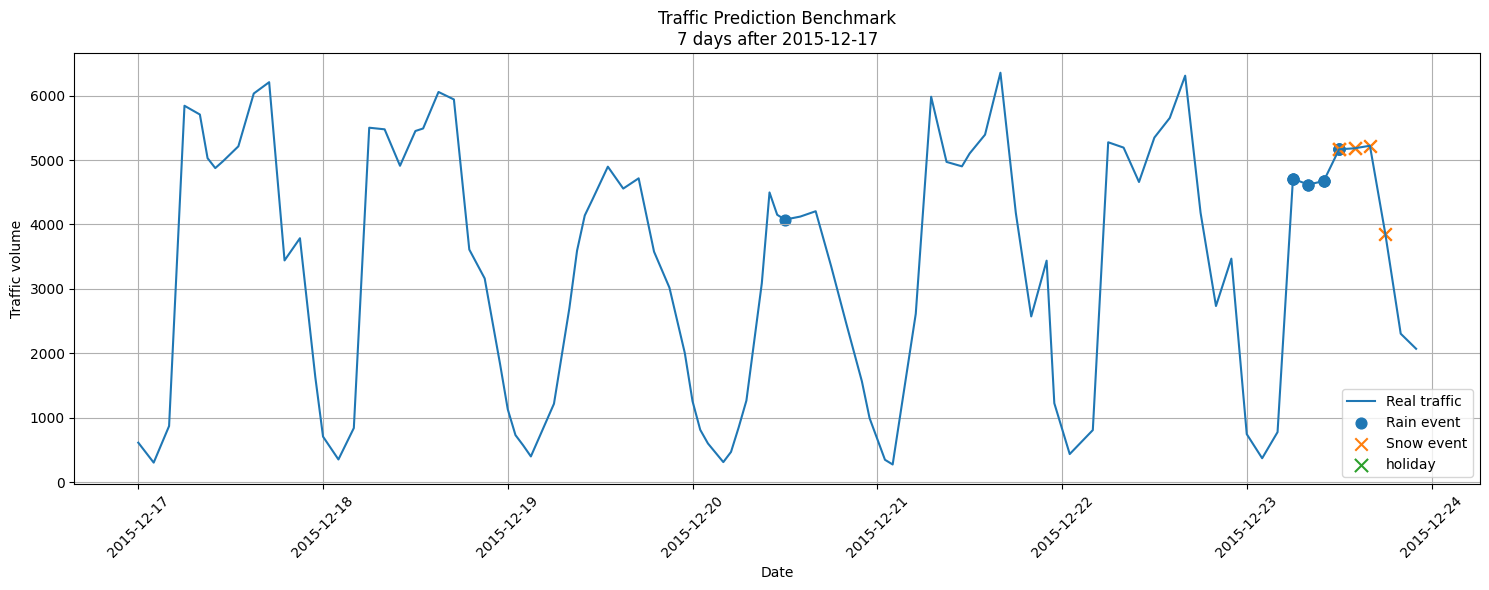

In [41]:


chosen_date = '2015-12-17'   # <- CHANGE THIS
# ---------------------------------------------------------
# Extract 7 days after chosen date
# ---------------------------------------------------------
start_date = pd.to_datetime(chosen_date)
end_date = start_date + pd.Timedelta(days=7)

mask = (
    (traffic_df['date_time'] >= start_date) &
    (traffic_df['date_time'] < end_date)
)

dates_period = traffic_df.loc[mask, 'date_time']
y_real_period = traffic_df.loc[mask, 'traffic_volume']

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

plt.figure(figsize=(15,6))

plt.plot(
    dates_period,
    y_real_period,
    label='Real traffic'
)
# ---------------------------------------------------------
# Highlight special weather events
# ---------------------------------------------------------

rain_mask = traffic_df.loc[mask, 'rain_1h'] > 0
snow_mask = traffic_df.loc[mask, 'snow_1h'] > 0
holiday_mask = traffic_df.loc[mask, 'isHoliday'] > 0

plt.scatter(
    dates_period[rain_mask],
    y_real_period[rain_mask],
    marker='o',
    s=60,
    label='Rain event'
)

plt.scatter(
    dates_period[snow_mask],
    y_real_period[snow_mask],
    marker='x',
    s=80,
    label='Snow event'
)
plt.scatter(
    dates_period[holiday_mask],
    y_real_period[holiday_mask],
    marker='x',
    s=90,
    label='holiday'
)

# ---------------------------------------------------------
# Cosmetics
# ---------------------------------------------------------

plt.xlabel('Date')
plt.ylabel('Traffic volume')

plt.title(
    f'Traffic Prediction Benchmark\n'
    f'7 days after {chosen_date}'
)

plt.legend()
plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

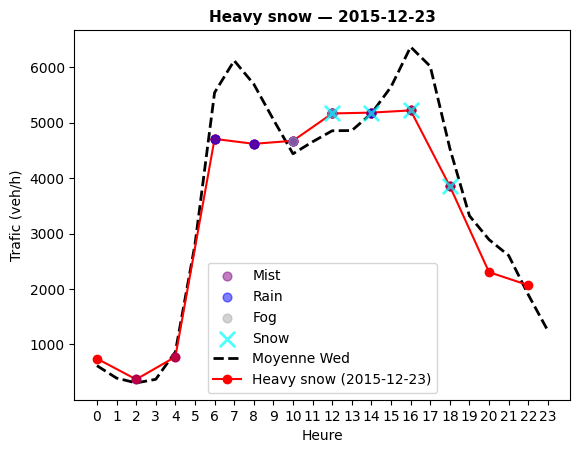

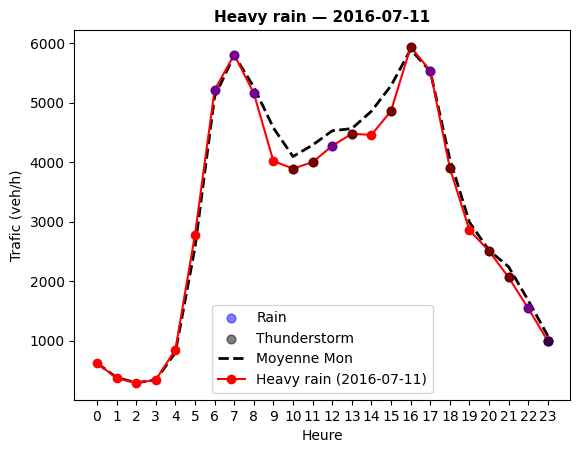

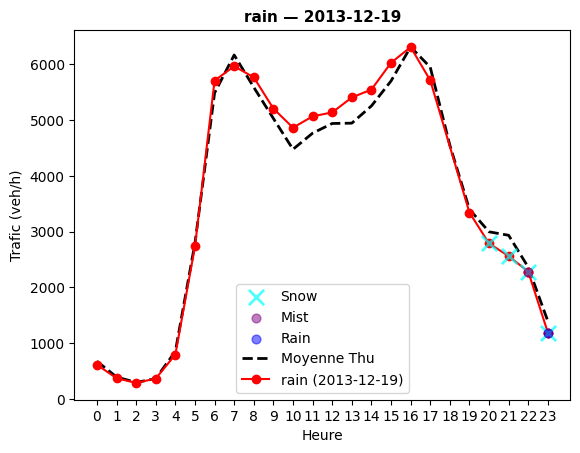

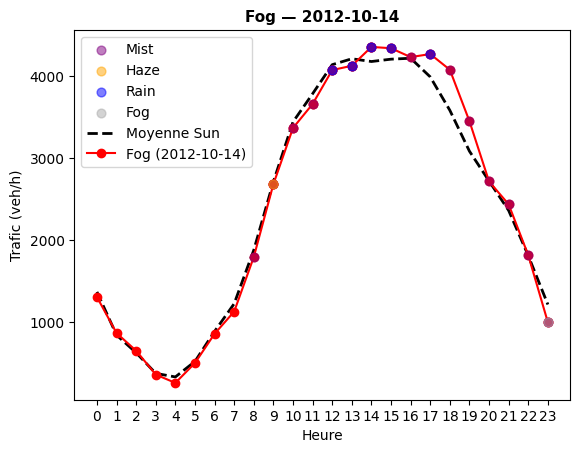

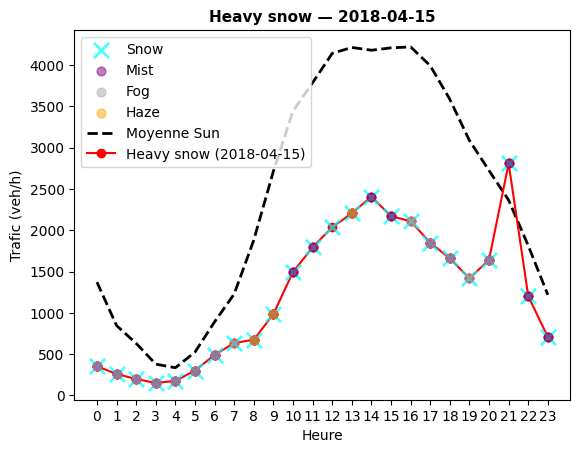

In [42]:
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
def plot_special_day(df, special_date, event_label):
    special_date = pd.to_datetime(special_date).date()
    special = df[df['date_time'].dt.date == special_date].sort_values('hour')
    weekday = special['dayOfWeek'].iloc[0]
    baseline = df[df['dayOfWeek'] == weekday].groupby('hour')['traffic_volume'].mean()

    excluded_weather = ['Clear', 'Clouds','Drizzle']

    weather_events = [
        w for w in special['weather_main'].unique()
        if w not in excluded_weather
    ]

    # Optional custom colors
    weather_colors = {
        'Clear': 'gold',
        'Clouds': 'gray',
        'Rain': 'blue',
        'Snow': 'cyan',
        'Mist': 'purple',
        'Fog': 'darkgray',
        'Thunderstorm': 'black',
        'Drizzle': 'deepskyblue',
        'Haze': 'orange',
        'Smoke': 'brown'
    }

    for weather in weather_events:

        weather_mask = special['weather_main'] == weather

        # Snow -> crosses
        if weather == 'Snow':

            plt.scatter(
                special.loc[weather_mask, 'hour'],
                special.loc[weather_mask, 'traffic_volume'],
                s=120,
                marker='x',
                linewidths=2,
                color=weather_colors.get(weather, 'cyan'),alpha=0.7,
                label=weather,
                zorder=5
            )

        # Everything else -> circles
        else:

            plt.scatter(
                special.loc[weather_mask, 'hour'],
                special.loc[weather_mask, 'traffic_volume'],
                s=40,
                marker='o',
                color=weather_colors.get(weather, 'green'),alpha=0.5,
                label=weather,
                zorder=5
            )
    plt.plot(baseline.index, baseline.values, 'k--', linewidth=2,
            label=f'Moyenne {day_names[weekday]}')
    plt.plot(special['hour'], special['traffic_volume'],
            color="red", marker='o',
            label=f'{event_label} ({special_date})')
    # ax.fill_between(special['hour'].values,
    #                 baseline.reindex(special['hour']).values,
    #                 special['traffic_volume'].values,
    #                 alpha=0.2, color='blue')
    plt.title(f'{event_label} — {special_date}', fontsize=11, fontweight='bold')
    plt.xlabel('Heure')
    plt.ylabel('Trafic (veh/h)')
    plt.legend()
    plt.xticks(range(0, 24))
    plt.show()

plot_special_day(traffic_df,'2015-12-23','Heavy snow')
plot_special_day(traffic_df,'2016-07-11','Heavy rain')
plot_special_day(traffic_df,'2013-12-19','rain')
plot_special_day(traffic_df,'2012-10-14','Fog')
plot_special_day(traffic_df,'2018-04-15','Heavy snow')

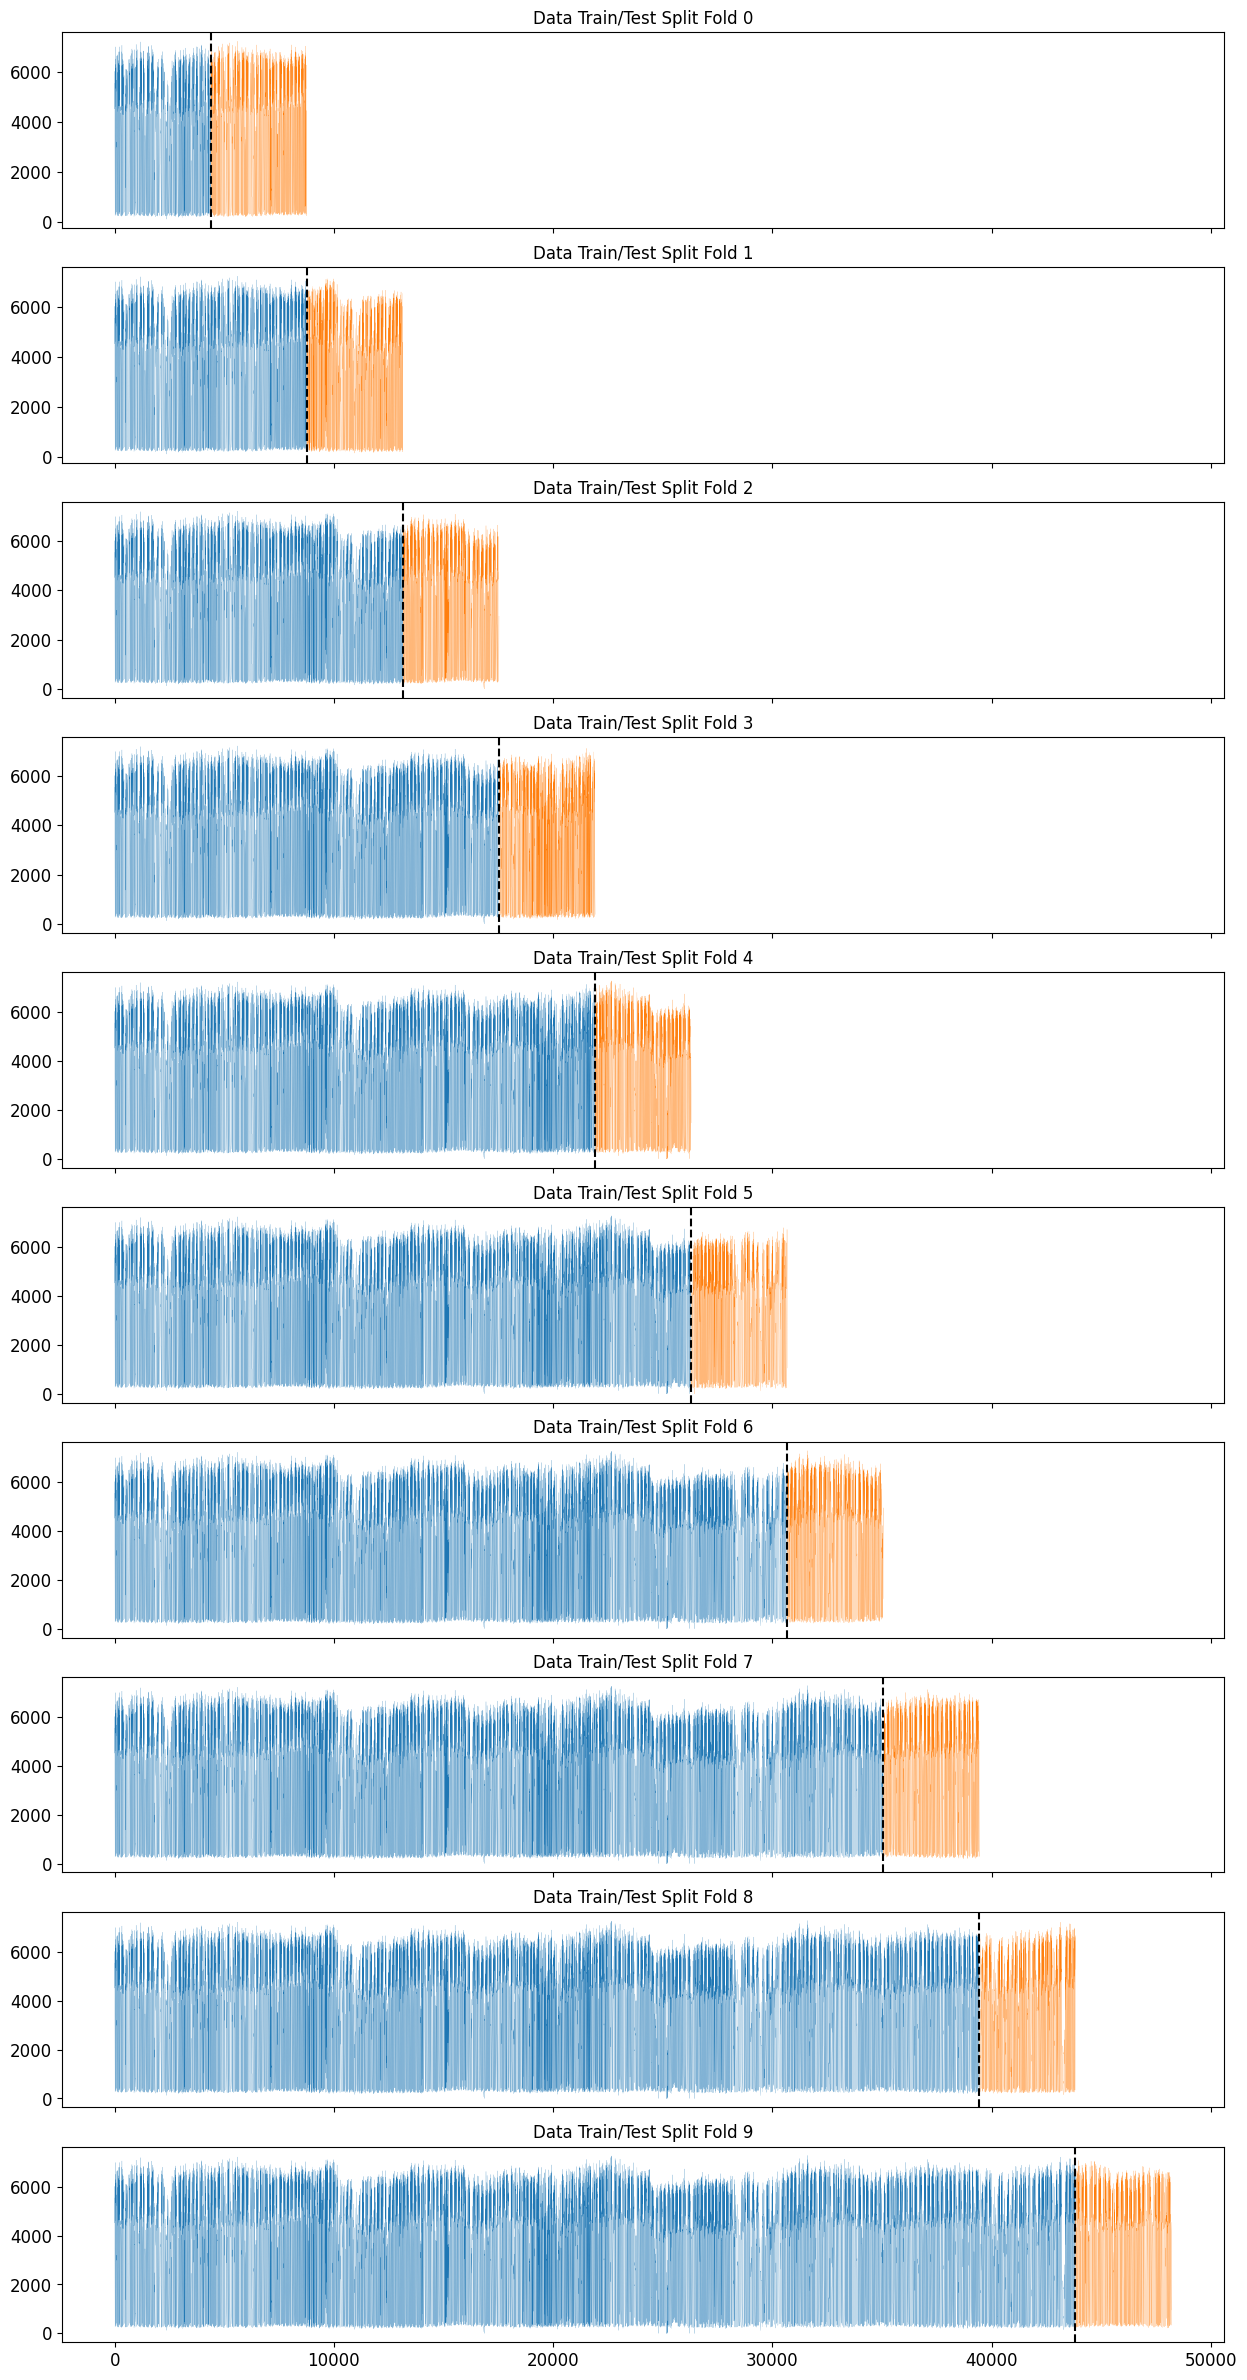

In [43]:
tss = TimeSeriesSplit(n_splits = 10, gap = 0)
#traffic_df.set_index('date_time',inplace=True)

fig, axs = plt.subplots(10, 1, figsize = (15, 30), sharex = True)
fold = 0

for train_idx, val_idx in tss.split(traffic_df):

    train = traffic_df.iloc[train_idx]
    test = traffic_df.iloc[val_idx]

    train['traffic_volume'].plot(ax = axs[fold],
                                 label = 'Training Set',
                                 title = f'Data Train/Test Split Fold {fold}',
                                 fontsize = 12,
                                 linewidth = 0.1)

    test['traffic_volume'].plot(ax = axs[fold],
                                label = 'Test Set',
                                linewidth = 0.1)

    axs[fold].axvline(test.index.min(),
                      color = 'black',
                      ls = '--')
    fold += 1

plt.show()

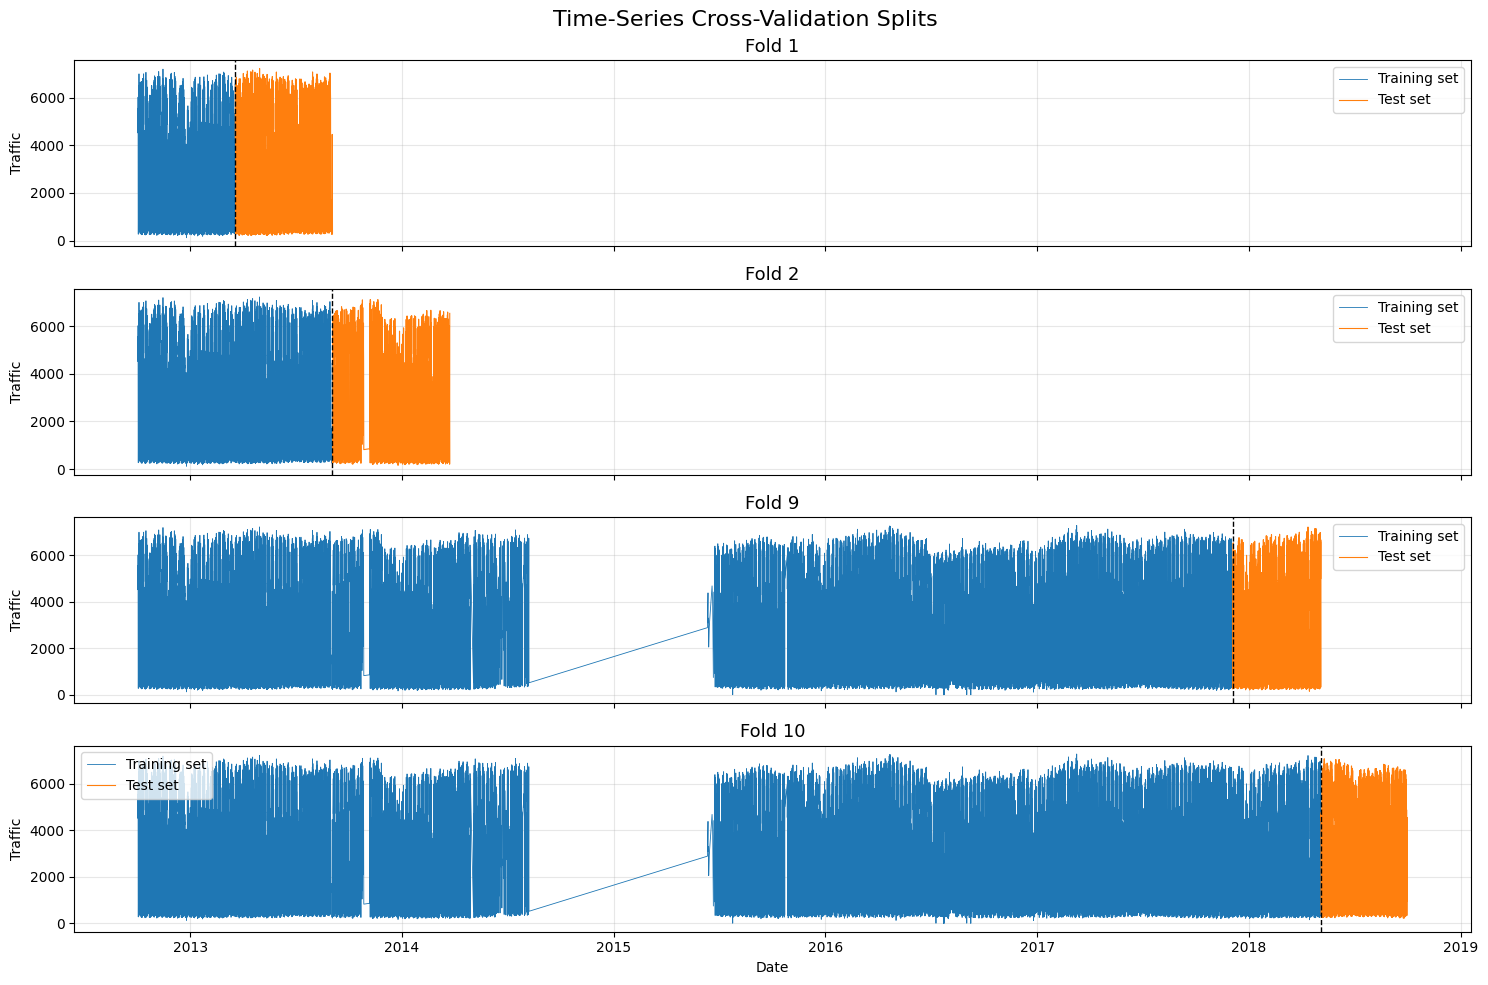

In [44]:
from sklearn.model_selection import TimeSeriesSplit

# =========================================================
# Cleaner visualization for report
# Only folds: 1, 2, ..., 10
# =========================================================

plt.style.use('default')

tss = TimeSeriesSplit(n_splits=10)

# Folds to display
selected_folds = [0, 1, 8, 9]   # Fold 1, Fold 2, Fold 10

fig, axs = plt.subplots(
    len(selected_folds), 1,
    figsize=(15, 10),
    sharex=True
)

for plot_id, (train_idx, test_idx) in enumerate(tss.split(traffic_df)):

    if plot_id not in selected_folds:
        continue

    # -----------------------------------------------------
    # Select axis
    # -----------------------------------------------------

    ax = axs[selected_folds.index(plot_id)]

    # -----------------------------------------------------
    # Data
    # -----------------------------------------------------

    train = traffic_df.iloc[train_idx]
    test = traffic_df.iloc[test_idx]

    # -----------------------------------------------------
    # Plot training
    # -----------------------------------------------------

    ax.plot(
        train['date_time'],
        train['traffic_volume'],
        label='Training set',
        linewidth=0.6
    )

    # -----------------------------------------------------
    # Plot testing
    # -----------------------------------------------------

    ax.plot(
        test['date_time'],
        test['traffic_volume'],
        label='Test set',
        linewidth=0.8
    )

    # -----------------------------------------------------
    # Separation line
    # -----------------------------------------------------

    ax.axvline(
        test['date_time'].min(),
        color='black',
        linestyle='--',
        linewidth=1
    )

    # -----------------------------------------------------
    # Titles
    # -----------------------------------------------------

    fold_name = plot_id + 1

    if fold_name == 10:
        title_text = 'Fold 10'
        test.to_csv("test.csv")
    else:
        title_text = f'Fold {fold_name}'

    if fold_name ==9:
        test.to_csv("test9.csv")

    ax.set_title(title_text, fontsize=13)

    ax.set_ylabel('Traffic')

    ax.grid(True, alpha=0.3)

    ax.legend()

# =========================================================
# Global formatting
# =========================================================

axs[-1].set_xlabel('Date')

fig.suptitle(
    'Time-Series Cross-Validation Splits',
    fontsize=16
)

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.savefig("plots/time-series CV splits.png")
plt.show()

In [45]:
from sklearn.linear_model import LassoCV
tss = TimeSeriesSplit(n_splits = 10, gap = 0)
for fold_id, (train_index, test_index) in enumerate(tss.split(traffic_df)):
    # Split data sequentially
    X_tr, X_te = X2.iloc[train_index], X2.iloc[test_index]
    y_tr, y_te = y[train_index], y[test_index]

    X_tr = preprocessor_test2.fit_transform(X_tr)
    X_te = preprocessor_test2.transform(X_te)

    inner_tss = TimeSeriesSplit(n_splits=5)
    LassoCV_reg = LassoCV(cv=inner_tss, random_state=42).fit(X_tr, y_tr)
    y_pred_lassoCV = LassoCV_reg.predict(X_te)

    print("R2:", r2_score(y_te, y_pred_lassoCV))
    print("RMSE:", np.sqrt(mean_squared_error(y_te, y_pred_lassoCV)))

    feature_names = preprocessor_test2.get_feature_names_out()
    coef_df = pd.DataFrame({
        'feature': feature_names,
        'coefficient': LassoCV_reg.coef_.round(2)
    })
    coef_df.to_csv(f'Coef {fold_id+1}.csv')
    coef_df['abs_coef'] = np.abs(coef_df['coefficient'])
    #print(coef_df.sort_values('abs_coef', ascending=False))

    plt.scatter(y_te, y_pred_lassoCV, c='y', alpha = 0.3)
    plt.plot(y_te, y_te, c='r', alpha=0.6, ls='--')
    plt.xlim(y_te.min()-1, y_te.max()+1)
    plt.ylim(y_te.min()-1, y_te.max()+1)
    plt.xlabel('Observed target')
    plt.ylabel('Predicted target')
    #plt.show()
    plt.close()

R2: 0.6820145391776067
RMSE: 1166.002483307308
R2: 0.6725755846290244
RMSE: 1120.8442460960262
R2: 0.6844095727337441
RMSE: 1122.3464689345435
R2: 0.6815618369891602
RMSE: 1146.409008776039
R2: 0.6277113590646657
RMSE: 1201.4354295964472
R2: 0.65801370055021
RMSE: 1097.461577307459
R2: 0.6724420156386761
RMSE: 1137.8415423043411
R2: 0.6687873340058178
RMSE: 1164.9759237640244
R2: 0.6480035803641806
RMSE: 1165.063890761478
R2: 0.6669011591554749
RMSE: 1127.9146294886937


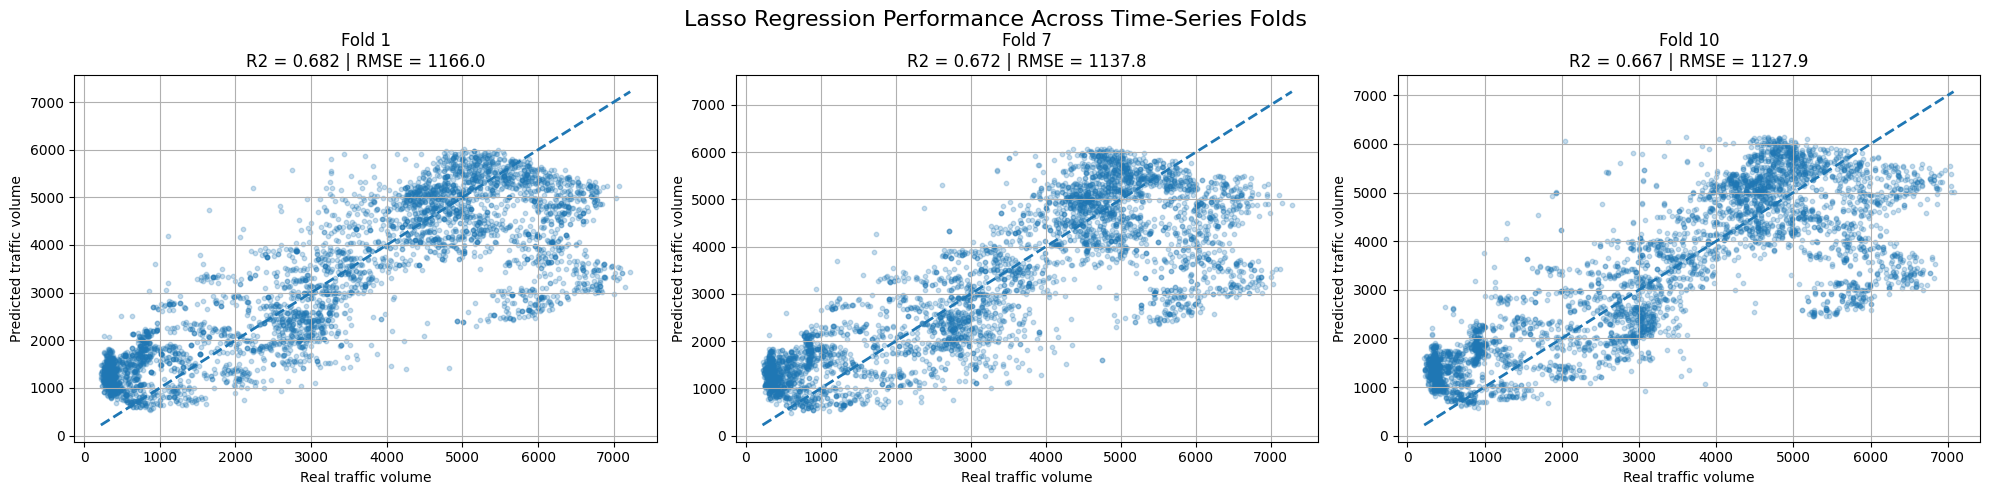

In [46]:
outer_tss = TimeSeriesSplit(n_splits=10)
plt.style.use('default')
# Folds we want to display in the report
selected_folds = [0, 6, 9]   # 1st, 7th, last

# =========================================================
# Create figure
# =========================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for fold_id, (train_index, test_index) in enumerate(outer_tss.split(traffic_df)):

    # -----------------------------------------------------
    # Keep only desired folds
    # -----------------------------------------------------

    if fold_id not in selected_folds:
        continue

    # -----------------------------------------------------
    # Split
    # -----------------------------------------------------

    X_tr, X_te = X2.iloc[train_index], X2.iloc[test_index]
    y_tr, y_te = y[train_index], y[test_index]

    # -----------------------------------------------------
    # Preprocessing
    # -----------------------------------------------------

    X_tr = preprocessor_test2.fit_transform(X_tr)
    X_te = preprocessor_test2.transform(X_te)

    # -----------------------------------------------------
    # Inner time-series CV for alpha selection
    # -----------------------------------------------------

    inner_tss = TimeSeriesSplit(n_splits=5)

    LassoCV_reg = LassoCV(
        cv=inner_tss,
        random_state=42,
        max_iter=10000
    )

    LassoCV_reg.fit(X_tr, y_tr)

    # -----------------------------------------------------
    # Prediction
    # -----------------------------------------------------

    y_pred = LassoCV_reg.predict(X_te)

    # -----------------------------------------------------
    # Metrics
    # -----------------------------------------------------

    r2 = r2_score(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))

    # -----------------------------------------------------
    # Plot
    # -----------------------------------------------------

    ax_idx = selected_folds.index(fold_id)
    ax = axes[ax_idx]

    ax.scatter(
        y_te,
        y_pred,
        alpha=0.25,
        s=10
    )

    # Perfect prediction line
    min_val = min(y_te.min(), y_pred.min())
    max_val = max(y_te.max(), y_pred.max())

    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        '--',
        linewidth=2
    )

    ax.set_title(
        f'Fold {fold_id+1}\n'
        f'R2 = {r2:.3f} | RMSE = {rmse:.1f}'
    )

    ax.set_xlabel('Real traffic volume')
    ax.set_ylabel('Predicted traffic volume')

    ax.grid(True)

# =========================================================
# Global title and formatting
# =========================================================

fig.suptitle(
    'Lasso Regression Performance Across Time-Series Folds',
    fontsize=16
)

plt.tight_layout()

# Slight spacing correction for report aesthetics
plt.subplots_adjust(top=0.85)

plt.savefig("plots/LassoReg 1 7 10.png")
plt.show()

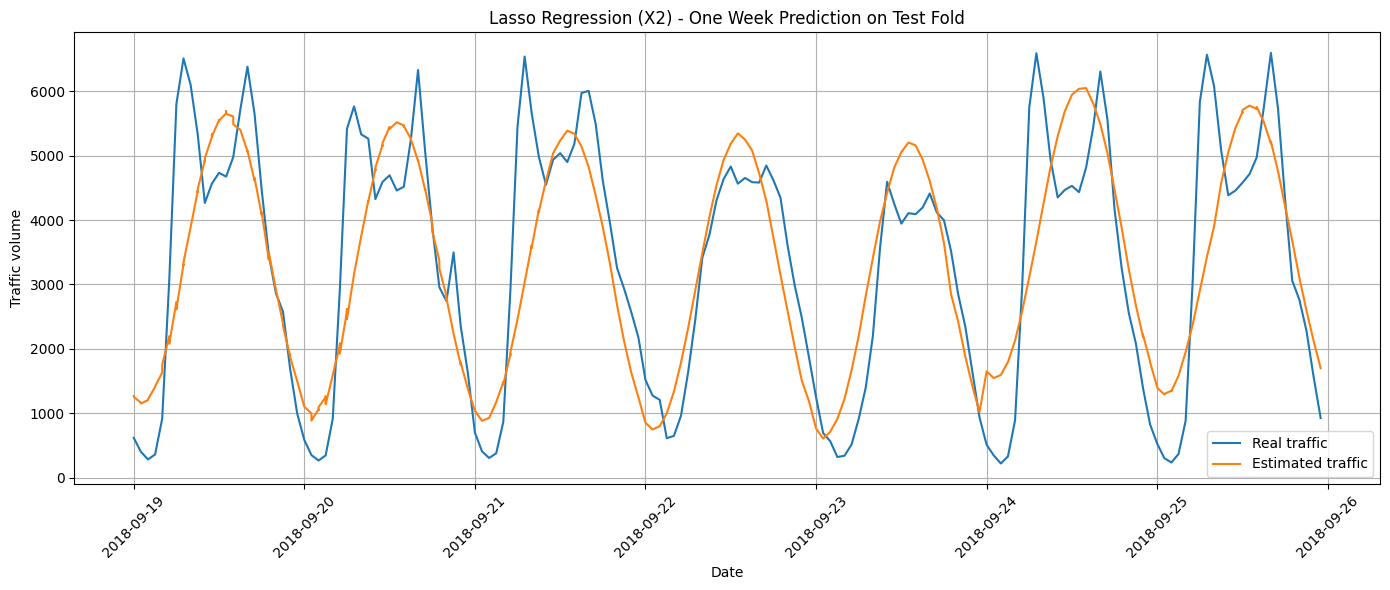

In [47]:
dates_test = traffic_df.iloc[test_index]['date_time'].reset_index(drop=True)

# first week of the fold
start_date = dates_test.iloc[4000]
end_date = start_date + pd.Timedelta(days=7)

week_mask = (dates_test >= start_date) & (dates_test < end_date)

dates_week = dates_test[week_mask]

y_real_week = y_te[week_mask]
y_pred_week = y_pred_lassoCV[week_mask]

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

plt.figure(figsize=(14,6))

plt.plot(dates_week, y_real_week, label='Real traffic')
plt.plot(dates_week, y_pred_week, label='Estimated traffic')

plt.xlabel('Date')
plt.ylabel('Traffic volume')
plt.title('Lasso Regression (X2) - One Week Prediction on Test Fold')

plt.legend()
plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("plots/LassoX2_1week.png")
plt.show()

In [48]:
for fold_id, (train_index, test_index) in enumerate(tss.split(traffic_df)):
    pass
    # Split data sequentially
    X_tr1, X_te1 = X1.iloc[train_index], X1.iloc[test_index]
    y_tr1, y_te1 = y[train_index], y[test_index]

    X_tr1 = preprocessor_test1.fit_transform(X_tr1)
    X_te1 = preprocessor_test1.transform(X_te1)

    inner_tss1 = TimeSeriesSplit(n_splits=5)
    LassoCV_reg1 = LassoCV(cv=inner_tss, random_state=42).fit(X_tr1, y_tr1)
    y_pred_lassoCV1 = LassoCV_reg1.predict(X_te1)

    print("R2:", r2_score(y_te1, y_pred_lassoCV1))
    print("RMSE:", np.sqrt(mean_squared_error(y_te1, y_pred_lassoCV1)))

    feature_names = preprocessor_test1.get_feature_names_out()
    coef_df = pd.DataFrame({
        'feature1': feature_names,
        'coefficient1': LassoCV_reg1.coef_.round(2)
    })
    #coef_df.to_csv(f'Coef {fold_id+1}.csv')
    coef_df['abs_coef'] = np.abs(coef_df['coefficient1'])
    print(coef_df.sort_values('abs_coef', ascending=False))
    coef_df.to_csv("coef_X1.csv")

    plt.scatter(y_te1, y_pred_lassoCV1, c='b', alpha = 0.3)
    plt.plot(y_te1, y_te1, c='r', alpha=0.6, ls='--')
    plt.xlim(y_te1.min()-1, y_te1.max()+1)
    plt.ylim(y_te1.min()-1, y_te1.max()+1)
    plt.xlabel('Observed target')
    plt.ylabel('Predicted target')
    #plt.show()
    plt.close()

R2: 0.6747342347422478
RMSE: 1179.274808961008
          feature1  coefficient1  abs_coef
3   num1__hour_cos      -1478.96   1478.96
2   num1__hour_sin       -475.84    475.84
0  num1__dayOfWeek       -286.09    286.09
1      num1__month         -0.00      0.00
4  num1__isHoliday         -0.00      0.00
R2: 0.6627305660355254
RMSE: 1137.5702563752377
          feature1  coefficient1  abs_coef
3   num1__hour_cos      -1536.96   1536.96
2   num1__hour_sin       -498.86    498.86
0  num1__dayOfWeek       -329.94    329.94
1      num1__month         -5.25      5.25
4  num1__isHoliday         -2.64      2.64
R2: 0.6844044546479029
RMSE: 1122.355569721174
          feature1  coefficient1  abs_coef
3   num1__hour_cos      -1496.72   1496.72
2   num1__hour_sin       -482.57    482.57
0  num1__dayOfWeek       -278.64    278.64
1      num1__month          0.00      0.00
4  num1__isHoliday         -0.00      0.00
R2: 0.6803184003596096
RMSE: 1148.6450757272962
          feature1  coefficient1  ab

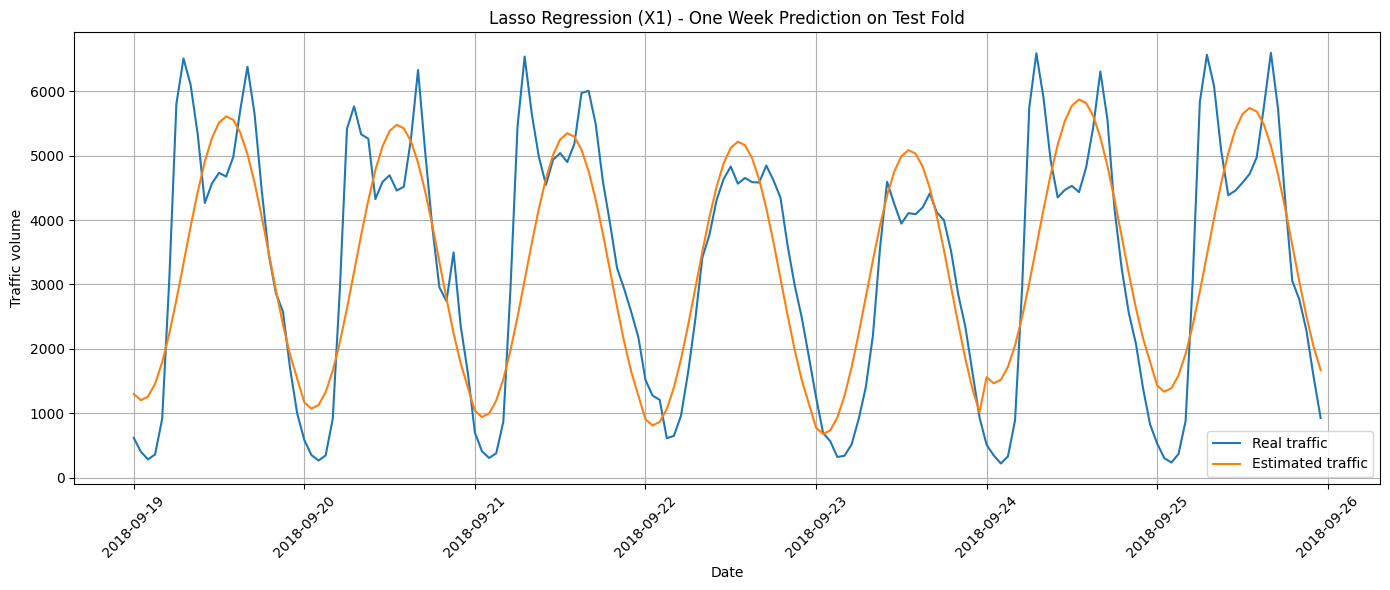

In [49]:
dates_test = traffic_df.iloc[test_index]['date_time'].reset_index(drop=True)

# first week of the fold
start_date1 = dates_test.iloc[4000]
end_date1 = start_date + pd.Timedelta(days=7)

week_mask1 = (dates_test >= start_date1) & (dates_test < end_date1)

dates_week1 = dates_test[week_mask]

y_real_week1 = y_te1[week_mask1]
y_pred_week1 = y_pred_lassoCV1[week_mask1]

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

plt.figure(figsize=(14,6))

plt.plot(dates_week1, y_real_week1, label='Real traffic')
plt.plot(dates_week1, y_pred_week1, label='Estimated traffic')

plt.xlabel('Date')
plt.ylabel('Traffic volume')
plt.title('Lasso Regression (X1) - One Week Prediction on Test Fold')

plt.legend()
plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("plots/LassoX1_1week.png")
plt.show()

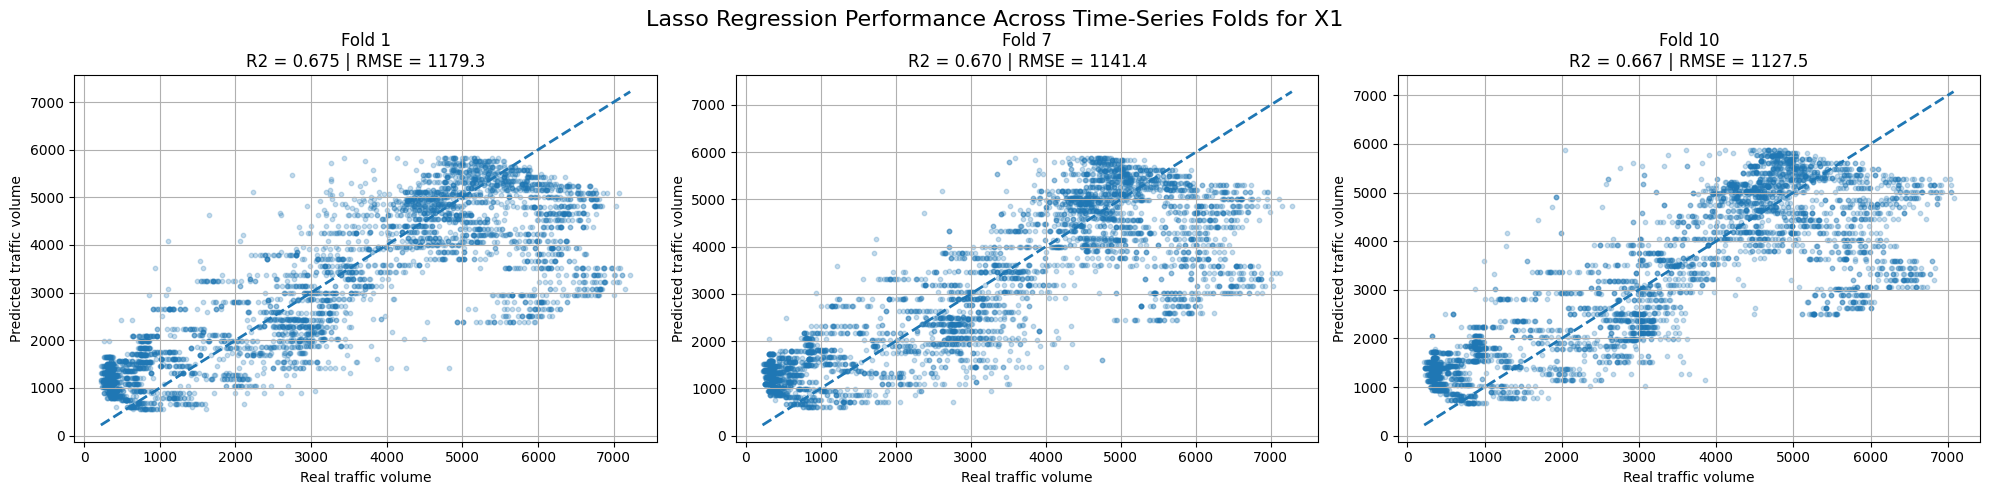

In [50]:
outer_tss = TimeSeriesSplit(n_splits=10)
plt.style.use('default')
# Folds we want to display in the report
selected_folds = [0, 6, 9]   # 1st, 7th, last

# =========================================================
# Create figure
# =========================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for fold_id, (train_index, test_index) in enumerate(outer_tss.split(traffic_df)):

    # -----------------------------------------------------
    # Keep only desired folds
    # -----------------------------------------------------

    if fold_id not in selected_folds:
        continue

    # -----------------------------------------------------
    # Split
    # -----------------------------------------------------

    X_tr1, X_te1 = X1.iloc[train_index], X1.iloc[test_index]
    y_tr1, y_te1 = y[train_index], y[test_index]
    # -----------------------------------------------------
    # Preprocessing
    # -----------------------------------------------------

    X_tr1 = preprocessor_test1.fit_transform(X_tr1)
    X_te1 = preprocessor_test1.transform(X_te1)

    # -----------------------------------------------------
    # Inner time-series CV for alpha selection
    # -----------------------------------------------------

    inner_tss = TimeSeriesSplit(n_splits=5)

    LassoCV_reg1 = LassoCV(
        cv=inner_tss,
        random_state=42,
        max_iter=10000
    )

    LassoCV_reg1.fit(X_tr1, y_tr1)

    # -----------------------------------------------------
    # Prediction
    # -----------------------------------------------------

    y_pred1 = LassoCV_reg1.predict(X_te1)

    # -----------------------------------------------------
    # Metrics
    # -----------------------------------------------------

    r21 = r2_score(y_te1, y_pred1)
    rmse1 = np.sqrt(mean_squared_error(y_te1, y_pred1))

    # -----------------------------------------------------
    # Plot
    # -----------------------------------------------------

    ax_idx1 = selected_folds.index(fold_id)
    ax1 = axes[ax_idx1]

    ax1.scatter(
        y_te1,
        y_pred1,
        alpha=0.25,
        s=10
    )

    # Perfect prediction line
    min_val1 = min(y_te1.min(), y_pred1.min())
    max_val1 = max(y_te1.max(), y_pred1.max())

    ax1.plot(
        [min_val1, max_val1],
        [min_val1, max_val1],
        '--',
        linewidth=2
    )

    ax1.set_title(
        f'Fold {fold_id+1}\n'
        f'R2 = {r21:.3f} | RMSE = {rmse1:.1f}'
    )

    ax1.set_xlabel('Real traffic volume')
    ax1.set_ylabel('Predicted traffic volume')

    ax1.grid(True)

# =========================================================
# Global title and formatting
# =========================================================

fig.suptitle(
    'Lasso Regression Performance Across Time-Series Folds for X1',
    fontsize=16
)

plt.tight_layout()

# Slight spacing correction for report aesthetics
plt.subplots_adjust(top=0.85)
plt.savefig("plots/LassoRegX1_1_7_10.png")
plt.show()


R2: 0.9563806575221142
RMSE: 408.15885816314443


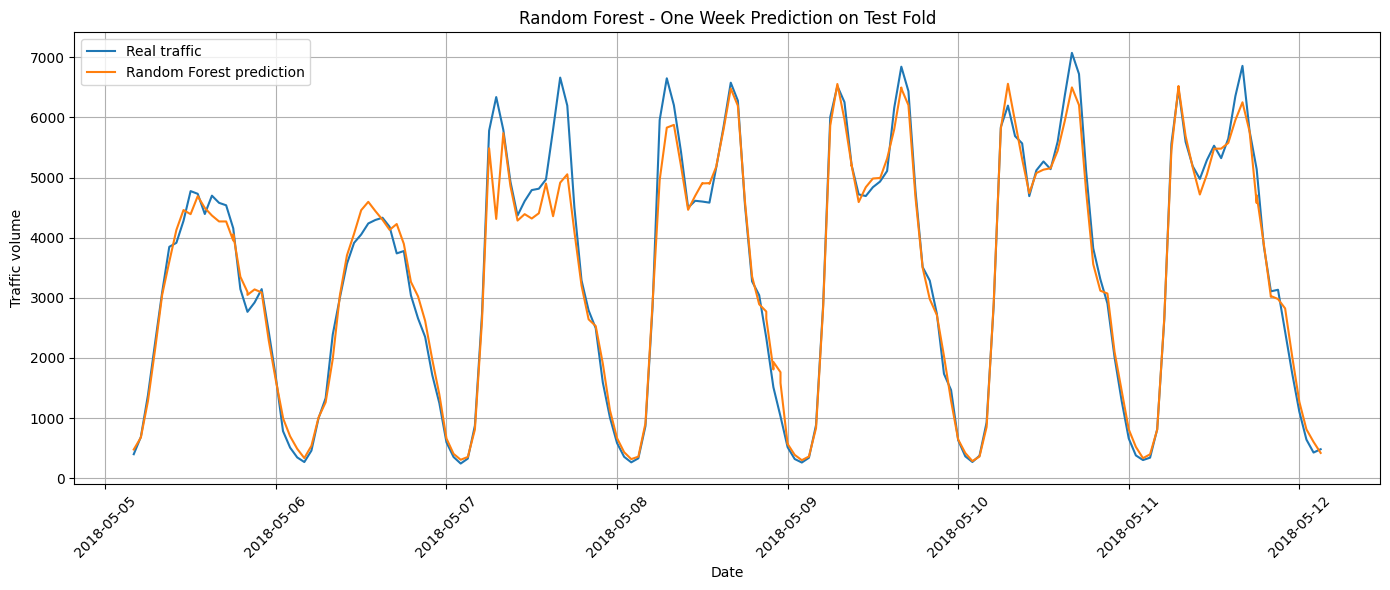

                           feature  importance
16             remainder__hour_cos    0.664375
15             remainder__hour_sin    0.174464
13            remainder__dayOfWeek    0.110514
11                 remainder__temp    0.029861
14                remainder__month    0.009184
12           remainder__clouds_all    0.005625
1         cat__weather_main_Clouds    0.001614
5           cat__weather_main_Mist    0.000864
3            cat__weather_main_Fog    0.000780
8           cat__weather_main_Snow    0.000660
0          cat__weather_main_Clear    0.000625
6           cat__weather_main_Rain    0.000570
4           cat__weather_main_Haze    0.000475
10  cat__weather_main_Thunderstorm    0.000261
2        cat__weather_main_Drizzle    0.000101


In [51]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit

# ---------------------------------------------------------
# Time series split
# ---------------------------------------------------------

tss = TimeSeriesSplit(n_splits=10)

# Take ONLY the last fold
for fold, (train_index2, test_index2) in enumerate(tss.split(X2)):

    if fold == tss.n_splits - 1:
        train_index = train_index2
        test_index = test_index2

X_tr, X_te = X2.iloc[train_index], X2.iloc[test_index]
y_tr, y_te = y[train_index], y[test_index]

# ---------------------------------------------------------
# Preprocessing
# ---------------------------------------------------------
# Random Forest does NOT require scaling,
# but we still need one-hot encoding.

preprocessor_rf = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features_test2)
    ],
    remainder='passthrough'
)

X_tr = preprocessor_rf.fit_transform(X_tr)
X_te = preprocessor_rf.transform(X_te)

# ---------------------------------------------------------
# Train Random Forest
# ---------------------------------------------------------

RF_reg = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

RF_reg.fit(X_tr, y_tr)

# ---------------------------------------------------------
# Predictions
# ---------------------------------------------------------

y_pred = RF_reg.predict(X_te)

print("R2:", r2_score(y_te, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_te, y_pred)))

# ---------------------------------------------------------
# Select ONE WEEK from the test fold
# ---------------------------------------------------------

dates_test = traffic_df.iloc[test_index]['date_time'].reset_index(drop=True)

start_date = dates_test.iloc[0]
end_date = start_date + pd.Timedelta(days=7)

week_mask = (dates_test >= start_date) & (dates_test < end_date)

dates_week = dates_test[week_mask]

y_real_week = y_te[week_mask]
y_pred_week = y_pred[week_mask]

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

plt.figure(figsize=(14,6))

plt.plot(dates_week, y_real_week, label='Real traffic')
plt.plot(dates_week, y_pred_week, label='Random Forest prediction')

plt.xlabel('Date')
plt.ylabel('Traffic volume')
plt.title('Random Forest - One Week Prediction on Test Fold')

plt.legend()
plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("plots/RF_1week.png")
plt.show()

# ---------------------------------------------------------
# Feature importance
# ---------------------------------------------------------

feature_names = preprocessor_rf.get_feature_names_out()

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': RF_reg.feature_importances_
})

importance_df = importance_df.sort_values(
    by='importance',
    ascending=False
)

print(importance_df.head(15))